# SI7016 Applied NLP, 2026-2
# Class 01 - parte 4
# Classifiers: Naive Bayes and Logistic Regression

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# reviews de peliculas
texts = [
    "Me encantó la película, muy buena",
    "Una historia excelente y conmovedora",
    "Pésima, no la recomiendo",
    "Actuación muy mala y aburrida",
    "Gran producción y buen guión",
    "Una pérdida de tiempo, muy lenta",
    "Maravillosa, la volvería a ver",
    "Demasiado predecible y sin emoción"
]
labels = [1, 1, 0, 0, 1, 0, 1, 0]

# Representación del texto: BoW vs TF-IDF

In [3]:
tvectorizer = TfidfVectorizer()
Xtfidf = tvectorizer.fit_transform(texts)

cvectorizer = CountVectorizer()
Xbow = cvectorizer.fit_transform(texts)

In [4]:
# matriz de características TFIDF
print(Xtfidf.toarray())

[[0.         0.         0.         0.44516984 0.         0.
  0.         0.         0.44516984 0.         0.         0.
  0.         0.32194353 0.         0.         0.         0.44516984
  0.32194353 0.         0.44516984 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.51970849 0.
  0.         0.         0.         0.51970849 0.         0.
  0.51970849 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.43555627 0.
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.38529838 0.         0.         0.         0.
  0.         0.53277424 0.         0.         0.         0.
  0.53277424 0.53277424 0.         0.         0.         0.
  0.        ]
 [0.53277424 0.53277424 0.         0.         0.  

In [5]:
# matriz de características BoW
print(Xbow.toarray())

[[0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0]]


# reto corto:

## Con el mismo corpus, crea TF-IDF con bigramas (1,2) y compara:
- tamaño del vocabulario
- 5 términos con mayor peso en un documento positivo y uno negativo

## Pregunta: ¿qué bigramas capturan mejor sentimiento que unigramas?


# Training and Test Datasets

In [6]:
# Training and Test data
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.25, random_state=42)

# Classifier: movie reviews with NAIVE BAYES

In [7]:
#  pipeline: TF-IDF + clasificador Naive Bayes
pipelineNB = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

# Entrenar modelo
pipelineNB.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('nb', MultinomialNB())])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



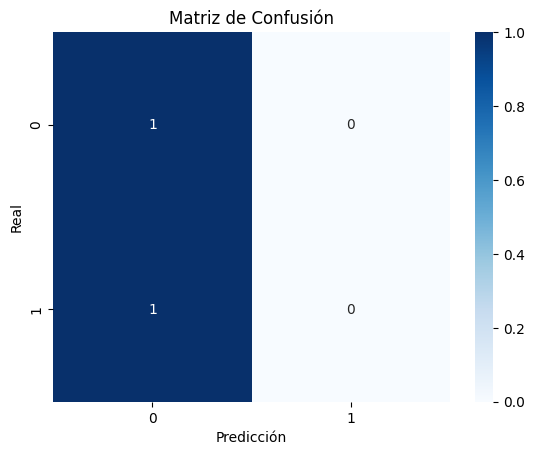

In [8]:
# evaluación del modelo NB
# Predicción
y_pred = pipelineNB.predict(X_test)

# Reporte de clasificación NB
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [9]:
# Clasificar nuevos reviews de peliculas con modelo NB
nuevas_opiniones = [
    "Fue una película muy inspiradora",
    "No me gustó, muy aburrida",
    "Una experiencia buena y emotiva"
]

# Predicción
predicciones = pipelineNB.predict(nuevas_opiniones)
for texto, pred in zip(nuevas_opiniones, predicciones):
    print(f"\nOpinión: '{texto}'\nSentimiento predicho: {'Positivo' if pred == 1 else 'Negativo'}")


Opinión: 'Fue una película muy inspiradora'
Sentimiento predicho: Positivo

Opinión: 'No me gustó, muy aburrida'
Sentimiento predicho: Negativo

Opinión: 'Una experiencia buena y emotiva'
Sentimiento predicho: Positivo


# Reto corto

## usa datasets con datos más grandes, ej: UCI/Yelp, news-reuters, etc
## Entrena dos variantes de NB:
* CountVectorizer() + MultinomialNB()
* TfidfVectorizer() + MultinomialNB()
## Pregunta: ¿cuál generaliza mejor en el dataset UCI/Yelp?
- Explica el resultado conectándolo con “conteos” vs “reponderación”.

# Classifier: movie reviews with Logistic Regression

In [10]:
# entrenar el modelo de RL

# Definir pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])

# Entrenar modelo
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LogisticRegression())])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



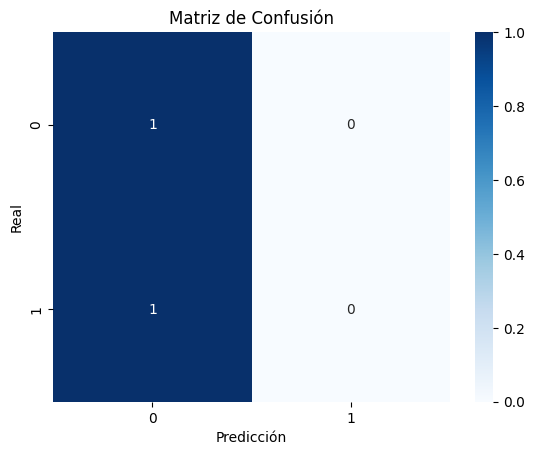

In [11]:
# evaluación del modelo RL
# Predicción
y_pred = pipeline.predict(X_test)

# Reporte de clasificación
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [12]:
# Clasificar nuevos reviews de peliculas con modelo RL
nuevas_opiniones = [
    "Fue una película muy inspiradora",
    "No me gustó, muy aburrida",
    "Una experiencia buena y emotiva"
]

# Predicción
predicciones = pipeline.predict(nuevas_opiniones)
for texto, pred in zip(nuevas_opiniones, predicciones):
    print(f"\nOpinión: '{texto}'\nSentimiento predicho: {'Positivo' if pred == 1 else 'Negativo'}")


Opinión: 'Fue una película muy inspiradora'
Sentimiento predicho: Positivo

Opinión: 'No me gustó, muy aburrida'
Sentimiento predicho: Negativo

Opinión: 'Una experiencia buena y emotiva'
Sentimiento predicho: Positivo


# Reto corto:

## En RL, prueba:
- unigramas vs bigramas (1,2)
- C=0.1, 1, 10 (regularización)

## Pregunta: ¿qué cambia más el desempeño: n-grams o regularización? ¿Por qué?

# SUPER RETO
# usar datasets de YELP etiquetados
# y adapte los clasificadores de NB y RL para entrenar, validar, y predecir

In [13]:
# URL del archivo en el repositorio UCI
import os
import zipfile
import urllib.request
import pandas as pd

# 1. URL del archivo ZIP de UCI
zip_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00331/sentiment%20labelled%20sentences.zip"
zip_filename = "sentiment_labelled_sentences.zip"
extract_dir = "sentiment_data"

# 2. Descargar el archivo zip si no existe
if not os.path.exists(zip_filename):
    print("Descargando archivo ZIP...")
    urllib.request.urlretrieve(zip_url, zip_filename)
    print("Descarga completada.")

# 3. Descomprimir el archivo zip
if not os.path.exists(extract_dir):
    print("Descomprimiendo archivo ZIP...")
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Descompresión completada.")

# 4. Leer el archivo yelp_labelled.txt
yelp_path = os.path.join(extract_dir, "sentiment labelled sentences", "yelp_labelled.txt")

df_yelp = pd.read_csv(yelp_path, sep="\t", header=None, names=["text", "label"])

# 5. Mostrar primeras filas
print("Primeras filas del DataFrame:")
print(df_yelp.head())

Descargando archivo ZIP...
Descarga completada.
Descomprimiendo archivo ZIP...
Descompresión completada.
Primeras filas del DataFrame:
                                                text  label
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1


# Realiza sobre el super reto:

## En Yelp:
- Entrena NB y RL con TF-IDF unigramas
- Reporta F1 (macro) y matriz de confusión
- Muestra 3 ejemplos donde NB falla y RL acierta (y viceversa)
## Pregunta: ¿qué patrón lingüístico explica esos errores? (negación, ironía, adjetivos raros, expresiones compuestas, etc.)